In [ ]:
!nvidia-smi

Thu Feb 12 20:47:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# @title 1. Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import timeit

# Check if GPU is available and set the device
device = "cuda"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import torch
print(torch.__version__)

2.6.0+cu124


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Neural Lyapunov-Like Function"

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-13-156906005.py", line 1, in <cell line: 0>
    get_ipython().run_line_magic('cd', '"/content/drive/MyDrive/Neural Lyapunov-Like Function"')
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                              ^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/magics/osm.py", line 342, in cd
    oldcwd = os.getcwd()
             ^^^^^^^^^^^
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception,

In [ ]:
# @title 2. System Dynamics (3-Machine Infinite Bus Model)

# Equilibrium point (deviation is calculated from this point)
delta1_star=0
delta2_star=0.9716
delta3_star=-0.791856
x_eq = np.array([delta1_star, delta2_star, delta3_star])

def f_value(x_tensor):
    """
    Computes the system dynamics dx/dt = f(x) for a batch of states.
    x is the deviation from the equilibrium point.
    """
    # Parameters for the 3-machine infinite bus system
    P1_star=0.1995
    P2_star=1.3644
    P3_star=0.0476
    Ma1=1.2
    Ma2=1
    Mf3=0.8
    Da1=0.2
    Da2=0.2
    Df3=0.2
    B12=-0.4151
    B13=-0.3317
    B23=-0.3308
    G12=0.4528
    G13=0.3659
    G23=0.4192

    # Using torch for operations to keep it on the device
    x_eq_tensor = torch.tensor(x_eq, dtype=x_tensor.dtype, device=x_tensor.device)
    x = x_tensor
    y = torch.zeros_like(x)

    delta1 = x[:, 0] + x_eq[0]
    delta2 = x[:, 1] + x_eq[1]
    delta3 = x[:, 2] + x_eq[2]

    P1 = G12 + G13 - (G12 * torch.cos(delta1 - delta2) + B12 * torch.sin(delta1 - delta2)) - (G13 * torch.cos(delta1 - delta3) + B13 * torch.sin(delta1 - delta3))
    P2 = G12 + G23 - (G12 * torch.cos(delta2 - delta1) + B12 * torch.sin(delta2 - delta1)) - (G23 * torch.cos(delta2 - delta3) + B23 * torch.sin(delta2 - delta3))
    P3 = G13 + G23 - (G13 * torch.cos(delta3 - delta1) + B13 * torch.sin(delta3 - delta1)) - (G23 * torch.cos(delta3 - delta2) + B23 * torch.sin(delta3 - delta2))

    y[:, 0] = Da1/Ma1 * (P1_star - P1) - x[:,0] / Ma1
    y[:, 1] = Da2/Ma2 * (P2_star - P2) - x[:,1] / Ma2
    y[:, 2] = Df3/Mf3 * (P3_star - P3) - x[:,2] / Mf3

    return y

In [ ]:
# @title 3. Lyapunov-like Network Architecture
class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        torch.manual_seed(42)

        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )

    def forward(self, x):
        phi = self.phi_network(x)
        V = torch.sum(phi**2, dim=-1, keepdim=True)
        return V

In [ ]:
# @title 4. System Linearization and Lipschitz Constant Functions (Corrected)

def linearize_dynamics(f_func, x0_tensor):
    """
    Computes the Jacobian of the dynamics f at x0 to get the linearized matrix A.
    Since our system has no external control input u, B is zero.
    """
    # Use torch's functional jacobian to get the A matrix (df/dx at x0)
    A = torch.autograd.functional.jacobian(f_func, x0_tensor)
    # Squeeze to remove batch dimensions of size 1
    A = A.squeeze()
    return A

def get_Lf(A_matrix):
    """
    Estimates the Lipschitz constant L_f for the dynamics using the linearized system.
    Using the operator norm (largest singular value) is a good estimate near the origin.
    """
    # The operator 2-norm is the largest singular value.
    L_f = torch.linalg.norm(A_matrix, ord=2)
    return L_f.item()

def get_Lv_and_threshold(model, verification_grid, L_f, tau):
    """
    Calculates the local Lipschitz constant L_v for the grid points and the
    corresponding tightened threshold.
    """
    # L_v is the norm of the gradient of V. We need to compute it with a graph.
    verification_grid.requires_grad_(True)
    V_grid = model(verification_grid)

    # Compute gradient dV/dx for the entire batch of grid points
    grad_V_grid = torch.autograd.grad(
        V_grid,
        verification_grid,
        grad_outputs=torch.ones_like(V_grid),
        create_graph=False  # No need for higher-order derivatives here
    )[0]

    verification_grid.requires_grad_(False) # Detach from graph

    # L_v is the maximum norm of the gradients over the verification set
    # Using L2 norm for the gradient vector at each point
    L_v = torch.max(torch.norm(grad_V_grid, p=2, dim=1))

    # The tightened threshold: -L_v * (1 + L_f) * tau
    threshold = -L_v * (1 + L_f) * tau

    return L_v.item(), threshold.item()

In [ ]:
# @title 5. Training and Verification Setup (Modified)
# Hyperparameters
N_SAMPLES = 20000
D_IN = 3
H1 = 16 #32
D_PHI_OUT = 3
LEARNING_RATE = 0.001
EPOCHS = 2000

# NEW: Small positive constant for asymptotic stability condition V_dot <= -delta
DELTA = 1e-6

# Verification parameters
VERIFICATION_RADIUS = 1
GRID_DENSITY = 300
TAU = VERIFICATION_RADIUS * np.sqrt(D_IN) / GRID_DENSITY

# Instantiate the model and optimizer
model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Create training data
x = torch.randn(N_SAMPLES, D_IN)
x = x / torch.norm(x, dim=1, keepdim=True) * (VERIFICATION_RADIUS * torch.rand(N_SAMPLES, 1))
x = x.to(device)
x.requires_grad_(True)

# The origin
x_0 = torch.zeros([1, D_IN]).to(device)

print(f"Model Architecture:\n{model}")
print(f"\nTraining with {N_SAMPLES} samples for {EPOCHS} epochs.")
print(f"Verification will be performed in a ball of radius {VERIFICATION_RADIUS} with τ ≈ {TAU:.4f}")
print(f"Asymptotic stability delta: {DELTA}")

# Linearize the system at the origin to get the A matrix
A_matrix = linearize_dynamics(f_value, x_0)
L_f = get_Lf(A_matrix)
print(f"Linearized Matrix A:\n{A_matrix.cpu().numpy()}")
print(f"Estimated Lipschitz constant for dynamics, L_f: {L_f:.4f}")

Model Architecture:
LyapunovNetwork(
  (phi_network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

Training with 20000 samples for 2000 epochs.
Verification will be performed in a ball of radius 1 with τ ≈ 0.0058
Asymptotic stability delta: 1e-06
Linearized Matrix A:
[[-0.89226896 -0.02330161  0.08223727]
 [ 0.121605   -1.1912262   0.06962118]
 [-0.00684201 -0.11869561 -1.1244624 ]]
Estimated Lipschitz constant for dynamics, L_f: 1.2144


In [ ]:
# @title 6. Training Loop for Asymptotic Stability (Core Modification)
import timeit
import matplotlib.lines as mlines # For plotting legend

start_time = timeit.default_timer()
loss_history = []
verification_history = []

for epoch in range(EPOCHS + 1):
    model.train()
    # ---- TRAINING STEP ----
    x.requires_grad_(True)
    f_tensor = f_value(x)
    V_candidate = model(x)
    V_at_origin = model(x_0)

    grad_V = torch.autograd.grad(V_candidate, x, grad_outputs=torch.ones_like(V_candidate), create_graph=True)[0]
    lie_derivative = torch.sum(grad_V * f_tensor, dim=1, keepdim=True)

    # --- MODIFICATION 1: Loss Function ---
    # Original: loss = V_at_origin + 1.0 * F.relu(lie_derivative + V_candidate).mean()
    # New: We only penalize if the Lie derivative is not strictly negative.
    loss = V_at_origin + 1.0 * F.relu(lie_derivative + DELTA).mean()
    # ------------------------------------

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    x = x.detach()
    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f'Epoch {epoch:5d} | Loss: {loss.item():.6f} | V(0): {V_at_origin.item():.6f}')

        # ---- VERIFICATION STEP ----
        model.eval()
        with torch.no_grad():
            axis = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, GRID_DENSITY)
            grid = np.meshgrid(axis, axis, axis)
            grid_points = np.stack([g.ravel() for g in grid], axis=1)
            grid_points = grid_points[np.linalg.norm(grid_points, axis=1) <= VERIFICATION_RADIUS]
            verification_grid = torch.tensor(grid_points, dtype=torch.float32).to(device)

        verification_grid.requires_grad_(True)
        V_grid_for_grad = model(verification_grid)
        grad_V_grid = torch.autograd.grad(
            V_grid_for_grad,
            verification_grid,
            grad_outputs=torch.ones_like(V_grid_for_grad),
            create_graph=False
        )[0]

        with torch.no_grad():
            f_grid = f_value(verification_grid)
            lie_derivative_grid = torch.sum(grad_V_grid * f_grid, dim=1, keepdim=True)
            L_v = torch.max(torch.norm(grad_V_grid, p=2, dim=1))
            threshold = -L_v * (1 + L_f) * TAU

            # --- MODIFICATION 2: Verification Condition ---
            # Original: verified = (lie_derivative_grid + V_grid) < threshold
            # New: We check the Lie derivative directly against the tightened threshold.
            verified = lie_derivative_grid < threshold.item()
            # ---------------------------------------------

            verification_rate = verified.float().mean().item()
            verification_history.append(verification_rate)
            print(f'  [VERIFY] L_v≈{L_v.item():.4f} | Threshold={threshold.item():.6f} | % Verified: {verification_rate*100:.2f}%')


stop_time = timeit.default_timer()
print(f"\nTraining and verification finished in {stop_time - start_time:.2f} seconds.")


Epoch     0 | Loss: 0.009188 | V(0): 0.008756
  [VERIFY] L_v≈0.1480 | Threshold=-0.001892 | % Verified: 94.65%
Epoch   500 | Loss: 0.000000 | V(0): 0.000000
  [VERIFY] L_v≈0.1262 | Threshold=-0.001613 | % Verified: 99.26%
Epoch  1000 | Loss: 0.000000 | V(0): 0.000000
  [VERIFY] L_v≈0.1264 | Threshold=-0.001616 | % Verified: 99.26%
Epoch  1500 | Loss: 0.000000 | V(0): 0.000000
  [VERIFY] L_v≈0.1267 | Threshold=-0.001620 | % Verified: 99.26%
Epoch  2000 | Loss: 0.000000 | V(0): 0.000000
  [VERIFY] L_v≈0.1271 | Threshold=-0.001625 | % Verified: 99.26%

Training and verification finished in 22.11 seconds.


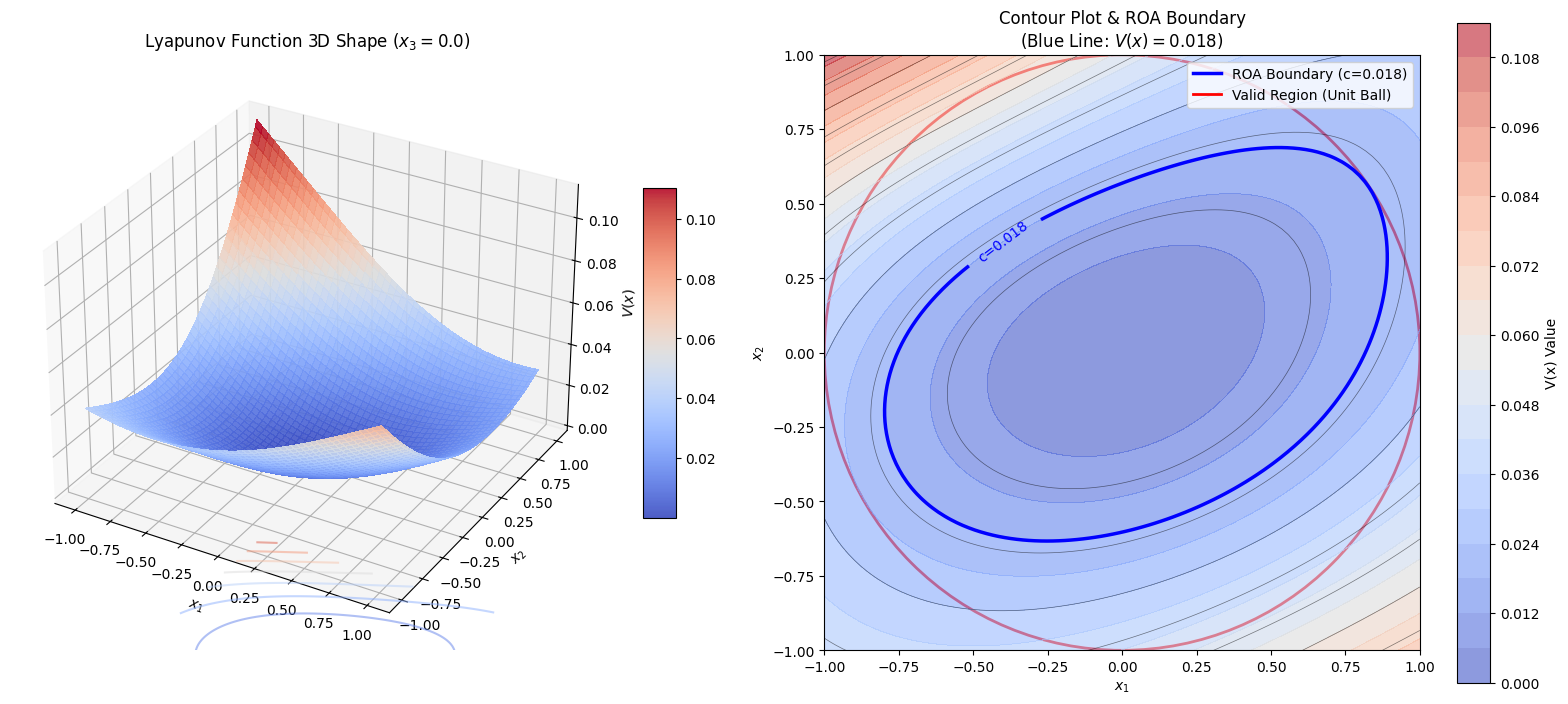


CALCULATING ROA AREA FOR c = 0.018
Total points in Unit Circle: 785107
Points inside ROA (V <= 0.018): 401343
🟢 ROA Area Percentage: 51.12%


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

# ==========================================
# Post-Training Visualization & Manual ROA Check
# ==========================================

# --- 🟢 USER SETTINGS: 修改这里 ---
C_LEVEL = 0.018  # <--- 在这里手动输入你想要测试的 Level Set 值 (c)
SLICE_VAL = 0.0 # x3 切片的位置，默认为 0
MC_SAMPLES = 1000000 # 蒙特卡洛采样的点数
RADIUS = 1.0    # 验证区域半径
# --------------------------------

def visualize_and_calculate_area(model, c_level, slice_val, radius):
    model.eval()

    # --- 1. 准备绘图数据 (Slice x3 = slice_val) ---
    res = 100
    X = np.linspace(-radius, radius, res)
    Y = np.linspace(-radius, radius, res)
    x1_mesh, x2_mesh = np.meshgrid(X, Y)

    # 构造输入 Tensor: x1, x2 变化，x3 固定
    # 假设输入维度是 3 (根据你之前的代码)
    x3_fixed = np.full_like(x1_mesh, slice_val)
    grid_slice = np.stack([x1_mesh.ravel(), x2_mesh.ravel(), x3_fixed.ravel()], axis=1)
    grid_tensor = torch.tensor(grid_slice, dtype=torch.float32).to(device)

    with torch.no_grad():
        V_slice = model(grid_tensor)

    V_matrix = V_slice.cpu().numpy().reshape(res, res)

    # --- 2. 开始绘图 ---
    fig = plt.figure(figsize=(16, 7))

    # [左图] Lyapunov 函数的 3D 形状
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax1.plot_surface(x1_mesh, x2_mesh, V_matrix, cmap=cm.coolwarm, alpha=0.9, antialiased=False)
    # 在底部投影等高线
    ax1.contour(x1_mesh, x2_mesh, V_matrix, zdir='z', offset=np.min(V_matrix)-0.1, cmap=cm.coolwarm, alpha=0.5)

    ax1.set_title(f'Lyapunov Function 3D Shape ($x_3={slice_val}$)')
    ax1.set_xlabel('$x_1$')
    ax1.set_ylabel('$x_2$')
    ax1.set_zlabel('$V(x)$')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

    # [右图] 2D 等高线图 (仿照你的参考代码)
    ax2 = fig.add_subplot(1, 2, 2)

    # A. 画出有效区域 (红色圆圈)
    circle = plt.Circle((0, 0), radius, color='r', linewidth=2.0, fill=False, label='Valid Region')
    ax2.add_artist(circle)

    # B. 画出背景等高线 (黑色细线)
    ax2.contour(x1_mesh, x2_mesh, V_matrix, levels=12, linewidths=0.5, colors='k', alpha=0.5)

    # C. 画出填充颜色 (Heatmap)
    c_fill = ax2.contourf(x1_mesh, x2_mesh, V_matrix, levels=20, alpha=0.6, cmap=cm.coolwarm)
    fig.colorbar(c_fill, ax=ax2, label='V(x) Value')

    # D. 画出你指定的 ROA 边界 (V(x) = C_LEVEL) - 蓝色粗线
    # 只有当 V_matrix 中存在该值时才画
    if np.min(V_matrix) < c_level < np.max(V_matrix):
        cs = ax2.contour(x1_mesh, x2_mesh, V_matrix, levels=[c_level],
                         linewidths=2.5, colors='b', linestyles='-')
        ax2.clabel(cs, inline=True, fontsize=10, fmt=f'c={c_level}')
    else:
        print(f"⚠️ Warning: Chosen C_LEVEL={c_level} is out of range [{np.min(V_matrix):.3f}, {np.max(V_matrix):.3f}] for this slice.")

    # 设置坐标轴
    ax2.set_xlim(-radius, radius)
    ax2.set_ylim(-radius, radius)
    ax2.set_xlabel('$x_1$')
    ax2.set_ylabel('$x_2$')
    ax2.set_title(f'Contour Plot & ROA Boundary\n(Blue Line: $V(x)={c_level}$)')
    ax2.set_aspect('equal')

    # 自定义图例
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='b', lw=2.5),
                    Line2D([0], [0], color='r', lw=2.0)]
    ax2.legend(custom_lines, [f'ROA Boundary (c={c_level})', 'Valid Region (Unit Ball)'], loc='upper right')

    plt.tight_layout()
    plt.show()

    # --- 3. Monte Carlo 面积占比计算 ---
    print("\n" + "="*40)
    print(f"CALCULATING ROA AREA FOR c = {c_level}")
    print("="*40)

    # 生成随机点 [-R, R]
    rnd_x1 = np.random.uniform(-radius, radius, MC_SAMPLES)
    rnd_x2 = np.random.uniform(-radius, radius, MC_SAMPLES)

    # 筛选在圆内的点
    mask_circle = (rnd_x1**2 + rnd_x2**2) <= radius**2
    valid_x1 = rnd_x1[mask_circle]
    valid_x2 = rnd_x2[mask_circle]
    total_valid_points = len(valid_x1)

    # 构造输入 (x3 = slice_val)
    x3_vals = np.full_like(valid_x1, slice_val)
    mc_inputs = np.stack([valid_x1, valid_x2, x3_vals], axis=1)
    mc_tensor = torch.tensor(mc_inputs, dtype=torch.float32).to(device)

    with torch.no_grad():
        V_mc = model(mc_tensor)

    V_mc_np = V_mc.cpu().numpy().flatten()

    # 统计有多少点 V <= c_level
    points_in_roa = np.sum(V_mc_np <= c_level)

    percentage = (points_in_roa / total_valid_points) * 100

    print(f"Total points in Unit Circle: {total_valid_points}")
    print(f"Points inside ROA (V <= {c_level}): {points_in_roa}")
    print(f"🟢 ROA Area Percentage: {percentage:.2f}%")

# --- 执行 ---
visualize_and_calculate_area(model, C_LEVEL, SLICE_VAL, RADIUS)

In [ ]:
# @title 6.1 Save the Trained Model

# 定义模型保存的路径和文件名
MODEL_SAVE_PATH = "lyapunov_only_model_3MG_new.pt"

# 保存模型的状态字典 (只保存学习到的参数)
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"✅ Model successfully saved to: {MODEL_SAVE_PATH}")

✅ Model successfully saved to: lyapunov_only_model_3MG_new.pt


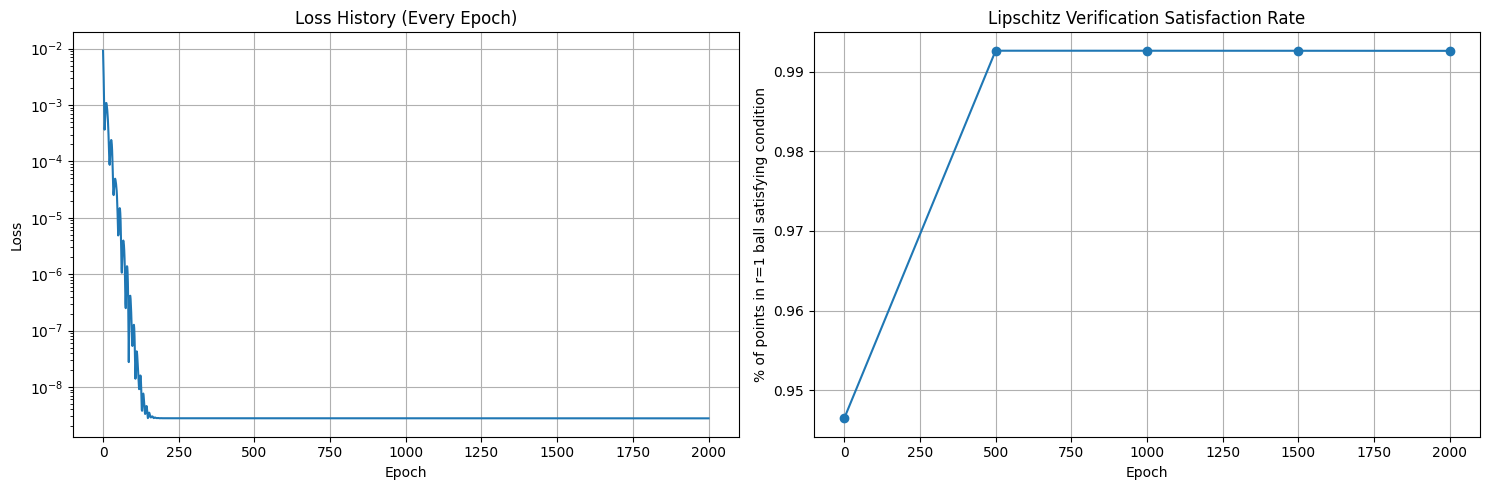

In [ ]:
# @title 7. Plot Training and Verification Results (Modified for Full History)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- 代码修改 START ---
# Plot Loss - 直接绘制loss_history列表，不带'o'标记
ax1.plot(loss_history)
# --- 代码修改 END ---

ax1.set_title('Loss History (Every Epoch)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')
ax1.grid(True)

# Plot Verification Rate - 验证率仍然是每500个epoch记录一次
epochs_recorded = np.arange(0, len(verification_history) * 500, 500)
ax2.plot(epochs_recorded, verification_history, 'o-')
ax2.set_title('Lipschitz Verification Satisfaction Rate')
ax2.set_xlabel('Epoch')
ax2.set_ylabel(f'% of points in r={VERIFICATION_RADIUS} ball satisfying condition')
ax2.grid(True)

plt.tight_layout()
plt.show()

✅ Model loaded from: lyapunov_only_model_3MG_new.pt


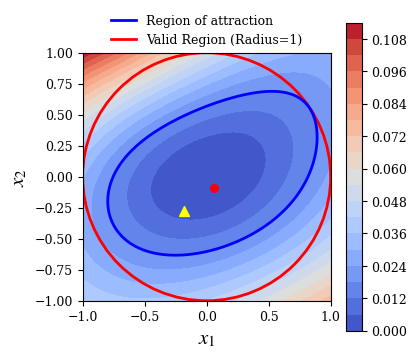

In [ ]:
# @title 9. Load Model and Plot Adjustable Level Set of V(x)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import logging
# 将 matplotlib 的字体管理器的日志级别设置为 ERROR，这样 WARNING 就不会显示了
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- 0. 全局字体与样式设置 (IEEE TPEL 风格) ---
plt.rcParams['font.family'] = 'Dejavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['mathtext.fontset'] = 'stix'
# --- 步骤 1: 重新定义模型结构和参数 ---
# 为了加载模型权重，我们需要先创建一个与保存时结构完全相同的模型实例。
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )
    def forward(self, x):
        phi = self.phi_network(x)
        return torch.sum(phi**2, dim=-1, keepdim=True)

# 定义与训练时相同的模型参数
D_IN, H1, D_PHI_OUT = 3, 16, 3
MODEL_LOAD_PATH = "lyapunov_only_model_3MG_new.pt"

# --- 步骤 2: 加载已保存的模型 ---
# 初始化一个同样结构的网络
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
# 加载已保存的权重
loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
loaded_model.eval()
print(f"✅ Model loaded from: {MODEL_LOAD_PATH}")

# --- 步骤 3: 准备绘图网格并计算V(x)值 ---
# 创建一个(-1, 1)范围内的网格
axis_range = np.linspace(-1, 1, 200) # 使用更密集的网格让图像更平滑
X1, X2 = np.meshgrid(axis_range, axis_range)
X3 = np.zeros_like(X1)
grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# 使用加载好的模型计算V(x)的值
with torch.no_grad():
    V_vals = loaded_model(grid_tensor).cpu().numpy().reshape(X1.shape)

# --- 步骤 4: 绘制2D等高线图 ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# -------------------------------------------------------------
# --- 您的可调项在这里 ---
# 您可以修改下面的 c_level 值来画出不同的等高线边界
c_level_to_plot = 0.018
# -------------------------------------------------------------

# 绘制背景：V(x) 的填充等高线图
c1 = ax.contourf(X1, X2, V_vals, levels=20, cmap='coolwarm')
fig.colorbar(c1, ax=ax)

# 绘制细的黑色等高线，增加细节
ax.contour(X1, X2, V_vals, levels=50, linewidths=0.5, colors='none')

# 绘制您指定的V(x) = c_level的边界线
# 这行代码完全仿照了您的示例: ax.contour(X, Y, V - c, 0)
ax.contour(X1, X2, V_vals - c_level_to_plot, levels=[0], colors='blue', linewidths=2)

# 绘制一个红色的圆圈作为参考区域
valid_region_circle = plt.Circle((0, 0), 1, color='r', linestyle='-', linewidth=2, fill=False)
ax.add_artist(valid_region_circle)
ax.scatter(-0.18, -0.28, color='yellow', marker='^', s=50, label='(-0.21, -0.3)')
ax.scatter(0.06, -0.09, color='red', marker='o', s=30, label='(-0.21, -0.3)')


# 设置图表属性
# ax.set_title('Region of Attraction Level Set')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal', adjustable='box')

# 创建图例
blue_line = mlines.Line2D([], [], color='blue', linewidth=2, label=f'Region of attraction')
red_dashed_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=2, label='Valid Region (Radius=1)')
# ax.legend(handles=[blue_line, red_dashed_line], loc='upper right')
ax.legend(handles=[blue_line, red_dashed_line],loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=1, frameon=False)
plt.savefig('ROA_Plot_3MG_600dpi.png', dpi=600, bbox_inches='tight', pad_inches=0.1, format='png')



plt.show()

✅ NN Model loaded successfully from: lyapunov_only_model_3MG_new.pt


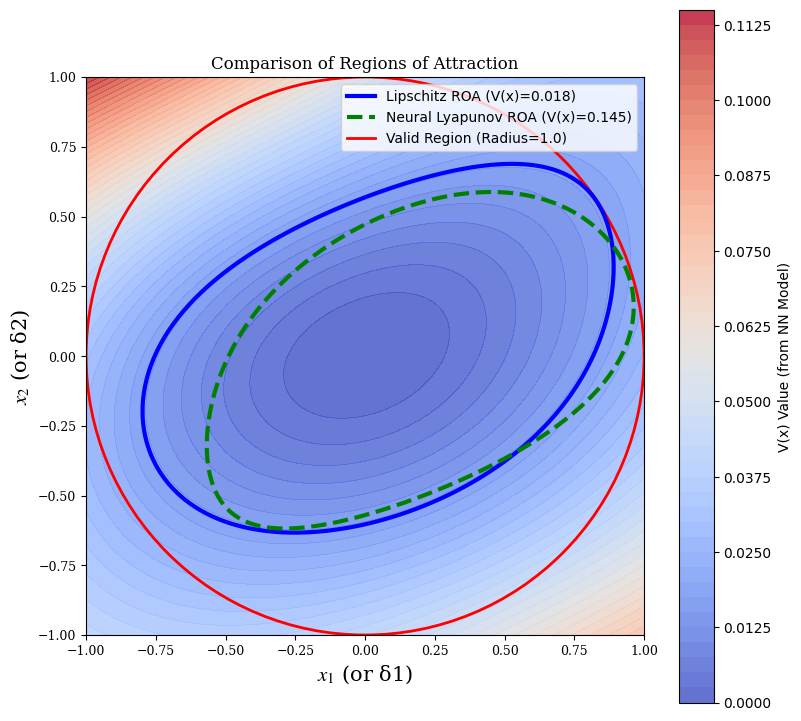


--- Calculating Area Percentages using Monte Carlo Simulation ---
Total random points generated: 1000000
Points falling inside the valid region (unit circle): 785165

--- Results ---
🔵 Lipschitz ROA covers approximately: 51.33% of the valid region.
🟢 Neural Lyapunov ROA covers approximately: 41.39% of the valid region.


In [ ]:
# @title 合并绘制两个ROA并计算面积占比 (Corrected)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
# REMOVED: from math import tanh, pi <- This was the cause of the error

# --- 步骤 1: 加载神经网络模型 (NN ROA) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )
    def forward(self, x):
        phi = self.phi_network(x)
        # V is defined as the sum of squares of the phi network outputs
        return torch.sum(phi**2, dim=-1, keepdim=True)

# 定义模型参数
D_IN, H1, D_PHI_OUT = 3, 16, 3
MODEL_LOAD_PATH = "lyapunov_only_model_3MG_new.pt"

# 初始化并加载模型
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
try:
    loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    loaded_model.eval()
    print(f"✅ NN Model loaded successfully from: {MODEL_LOAD_PATH}")
except FileNotFoundError:
    print(f"❌ Error: Model file not found at '{MODEL_LOAD_PATH}'. Please upload the model file.")
    # Exit or handle the error appropriately
    exit()


# --- 步骤 2: 定义手动函数 (Manual ROA) ---
def V_manual_func(x1, x2, x3):
    # This is the complex tanh function from your first code block
    # It's wrapped in a function for easier reuse, especially for area calculation
    # FIX: Use np.tanh for array operations instead of math.tanh
    # return np.tanh((0.28489392995834351 - 0.50537317991256714 * np.tanh((-0.9561578631401062 + 0.032332431524991989 * x1 + 0.014685286208987236 * x2 + 0.036234784871339798 * x3)) - 0.73633944988250732 * np.tanh((-0.79633277654647827 + 0.03550410270690918 * x1 + 0.02258789911866188 * x2 + 0.014865782111883163 * x3)) + 0.59411287307739258 * np.tanh((-0.77256643772125244 - 0.51164215803146362 * x1 + 0.94180291891098022 * x2 + 0.81391209363937378 * x3)) + 0.5439906120300293 * np.tanh((-0.73221635818481445 - 1.121950626373291 * x1 + 1.0651319026947021 * x2 - 1.1962651014328003 * x3)) + 0.84753018617630005 * np.tanh((-0.68941950798034668 + 1.7421015501022339 * x1 - 0.39744985103607178 * x2 + 0.67170512676239014 * x3)) + 0.57319861650466919 * np.tanh((-0.66498398780822754 - 0.9738619327545166 * x1 - 1.1657911539077759 * x2 - 0.44145447015762329 * x3)) - 0.13875547051429749 * np.tanh((-0.23850385844707489 - 0.18314631283283234 * x1 + 0.1538676917552948 * x2 + 0.13412509858608246 * x3)) + 0.64943641424179077 * np.tanh((0.68572044372558594 - 0.044353436678647995 * x1 - 0.0090756472200155258 * x2 - 0.0083716157823801041 * x3))))
    return np.tanh((0.2547767162322998 - 0.40649959444999695 * np.tanh((-0.81863176822662354 - 0.0090384278446435928 * x1 - 0.013131312094628811 * x2 + 0.041521396487951279 * x3)) + 0.57938146591186523 * np.tanh((-0.75359994173049927 - 0.53954482078552246 * x1 + 0.92261224985122681 * x2 + 0.67998963594436646 * x3)) + 0.41757205128669739 * np.tanh((-0.67490863800048828 - 0.58315283060073853 * x1 + 0.89021241664886475 * x2 - 0.96415972709655762 * x3)) - 0.52628910541534424 * np.tanh((-0.62299853563308716 - 0.011999349109828472 * x1 - 0.033917032182216644 * x2 + 0.0091249439865350723 * x3)) + 0.46008062362670898 * np.tanh((-0.56307429075241089 - 0.52978396415710449 * x1 - 1.0726710557937622 * x2 - 0.018526552245020866 * x3)) + 0.50381451845169067 * np.tanh((-0.55930608510971069 + 1.0690319538116455 * x1 - 0.45746400952339172 * x2 + 0.14372418820858002 * x3)) - 0.10210692137479782 * np.tanh((-0.1813347339630127 - 0.19584846496582031 * x1 + 0.12685427069664001 * x2 + 0.12084156274795532 * x3)) + 0.52733159065246582 * np.tanh((0.58528244495391846 + 0.018898408859968185 * x1 + 0.010899221524596214 * x2 + 0.019925747066736221 * x3))))


# --- 步骤 3: 准备绘图网格并计算 V(x) 值 ---
# 使用统一的、更密集的网格
axis_range = np.linspace(-1, 1, 200)
X1, X2 = np.meshgrid(axis_range, axis_range)
X3 = np.zeros_like(X1)

# 为 NN ROA 计算V值
grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
with torch.no_grad():
    V_vals_nn = loaded_model(grid_tensor).cpu().numpy().reshape(X1.shape)

# 为 Manual ROA 计算V值
V_vals_manual = V_manual_func(X1, X2, X3)


# --- 步骤 4: 绘制组合的2D等高线图 ---
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
plt.style.use('default')

# 定义两个ROA的等高线水平
c_level_nn = 0.018
c_level_manual = 0.145

# 绘制背景：使用NN模型的V(x)值作为填充背景
c1 = ax.contourf(X1, X2, V_vals_nn, levels=50, cmap='coolwarm', alpha=0.8)
fig.colorbar(c1, ax=ax, label='V(x) Value (from NN Model)')

# 绘制 NN ROA 的边界线 (蓝色)
ax.contour(X1, X2, V_vals_nn - c_level_nn, levels=[0], colors='blue', linewidths=3)

# 绘制 Manual ROA 的边界线 (绿色)
ax.contour(X1, X2, V_vals_manual - c_level_manual, levels=[0], colors='green', linewidths=3, linestyles='--')

# 绘制红色的有效区域圆圈
valid_region_circle = plt.Circle((0, 0), 1.0, color='red', linestyle='-', linewidth=2, fill=False)
ax.add_artist(valid_region_circle)

# 设置图表属性
ax.set_title('Comparison of Regions of Attraction')
ax.set_xlabel('$x_1$ (or δ1)')
ax.set_ylabel('$x_2$ (or δ2)')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')

# 创建图例
nn_line = mlines.Line2D([], [], color='blue', linewidth=3, label=f'Lipschitz ROA (V(x)={c_level_nn})')
manual_line = mlines.Line2D([], [], color='green', linestyle='--', linewidth=3, label=f'Neural Lyapunov ROA (V(x)={c_level_manual})')
valid_region_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=2, label='Valid Region (Radius=1.0)')
ax.legend(handles=[nn_line, manual_line, valid_region_line], loc='upper right')
plt.show()


# --- 步骤 5: 使用蒙特卡洛方法计算面积占比 ---
print("\n--- Calculating Area Percentages using Monte Carlo Simulation ---")
num_samples = 1000000  # 样本点数量，越多结果越准

# 在[-1, 1] x [-1, 1]的正方形内生成随机点
random_points = np.random.uniform(-1, 1, (num_samples, 2))
x1_rand, x2_rand = random_points[:, 0], random_points[:, 1]
x3_rand = np.zeros(num_samples)

# 筛选出落在有效区域（半径为1的圆）内的点
dist_sq_from_origin = x1_rand**2 + x2_rand**2
points_in_circle_mask = dist_sq_from_origin <= 1
total_points_in_circle = np.sum(points_in_circle_mask)

print(f"Total random points generated: {num_samples}")
print(f"Points falling inside the valid region (unit circle): {total_points_in_circle}")

# --- 计算 NN ROA 的面积 ---
# 仅对圆内的点进行计算
points_for_nn = torch.tensor(
    np.stack([x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask]], axis=1),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    v_nn_rand = loaded_model(points_for_nn).cpu().numpy().flatten()

points_in_nn_roa = np.sum(v_nn_rand <= c_level_nn)
percentage_nn = (points_in_nn_roa / total_points_in_circle) * 100

# --- 计算 Manual ROA 的面积 ---
# 仅对圆内的点进行计算
v_manual_rand = V_manual_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_manual_roa = np.sum(v_manual_rand <= c_level_manual)
percentage_manual = (points_in_manual_roa / total_points_in_circle) * 100

# --- 打印结果 ---
print("\n--- Results ---")
print(f"🔵 Lipschitz ROA covers approximately: {percentage_nn:.2f}% of the valid region.")
print(f"🟢 Neural Lyapunov ROA covers approximately: {percentage_manual:.2f}% of the valid region.")

✅ NN Model (Lipschitz) loaded successfully from: lyapunov_only_model_3MG.pt


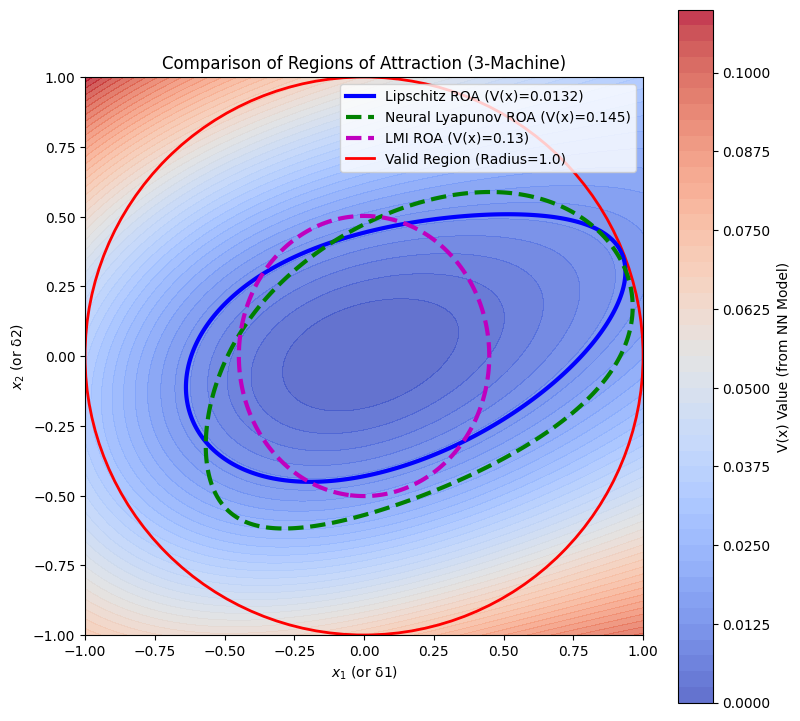


--- Calculating Area Percentages using Monte Carlo Simulation ---
Total random points generated: 1000000
Points falling inside the valid region (unit circle): 785282

--- Results ---
🔵 Lipschitz ROA covers approximately: 34.48% of the valid region.
🟢 Neural Lyapunov ROA covers approximately: 41.27% of the valid region.
🟣 LMI ROA covers approximately: 22.55% of the valid region.


In [ ]:
# @title 合并绘制三个ROA (Lipschitz, Neural, LMI) 并计算面积

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm

# --- 步骤 1: 加载神经网络模型 (NN ROA - 蓝色实线) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )
    def forward(self, x):
        phi = self.phi_network(x)
        # V is defined as the sum of squares of the phi network outputs
        return torch.sum(phi**2, dim=-1, keepdim=True)

# 定义模型参数 (来自你的 3MG 代码)
D_IN, H1, D_PHI_OUT = 3, 32, 3
MODEL_LOAD_PATH = "lyapunov_only_model_3MG.pt"

# 初始化并加载模型
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
try:
    loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    loaded_model.eval()
    print(f"✅ NN Model (Lipschitz) loaded successfully from: {MODEL_LOAD_PATH}")
except FileNotFoundError:
    print(f"❌ Error: Model file not found at '{MODEL_LOAD_PATH}'. Please upload the model file.")
    # Exit or handle the error appropriately
    exit()


# --- 步骤 2: 定义手动函数 (Neural Lyapunov ROA - 绿色虚线) ---
def V_manual_func(x1, x2, x3):
    # 这是你 3MG 代码里的 tanh 函数
    return np.tanh((0.2547767162322998 - 0.40649959444999695 * np.tanh((-0.81863176822662354 - 0.0090384278446435928 * x1 - 0.013131312094628811 * x2 + 0.041521396487951279 * x3)) + 0.57938146591186523 * np.tanh((-0.75359994173049927 - 0.53954482078552246 * x1 + 0.92261224985122681 * x2 + 0.67998963594436646 * x3)) + 0.41757205128669739 * np.tanh((-0.67490863800048828 - 0.58315283060073853 * x1 + 0.89021241664886475 * x2 - 0.96415972709655762 * x3)) - 0.52628910541534424 * np.tanh((-0.62299853563308716 - 0.011999349109828472 * x1 - 0.033917032182216644 * x2 + 0.0091249439865350723 * x3)) + 0.46008062362670898 * np.tanh((-0.56307429075241089 - 0.52978396415710449 * x1 - 1.0726710557937622 * x2 - 0.018526552245020866 * x3)) + 0.50381451845169067 * np.tanh((-0.55930608510971069 + 1.0690319538116455 * x1 - 0.45746400952339172 * x2 + 0.14372418820858002 * x3)) - 0.10210692137479782 * np.tanh((-0.1813347339630127 - 0.19584846496582031 * x1 + 0.12685427069664001 * x2 + 0.12084156274795532 * x3)) + 0.52733159065246582 * np.tanh((0.58528244495391846 + 0.018898408859968185 * x1 + 0.010899221524596214 * x2 + 0.019925747066736221 * x3))))

# --- 步骤 2.5: 定义 LMI Lyapunov 函数 (LMI ROA - 品红虚线) ---
def V_LMI_func(x1, x2, x3):
    # 这就是你给的那个 LMI 函数
    V = (x1*((726740612259899*x1)/1125899906842624 - (375005997332307*x2)/9671406556917033397649408 + (800829822797503*x3)/9671406556917033397649408)
         - x2*((375005997332307*x1)/9671406556917033397649408 - (580607185267217*x2)/1125899906842624 + (1553529711554555*x3)/18014398509481984)
         + x3*((800829822797503*x1)/9671406556917033397649408 - (1553529711554555*x2)/18014398509481984 + (5037159836491261*x3)/9007199254740992))
    return V

# --- 步骤 3: 准备绘图网格并计算 V(x) 值 ---
# 使用统一的、更密集的网格
axis_range = np.linspace(-1, 1, 200)
X1, X2 = np.meshgrid(axis_range, axis_range)
X3 = np.zeros_like(X1) # 2D 绘图，x3 切片为 0

# 为 NN ROA (Lipschitz) 计算V值
grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
with torch.no_grad():
    V_vals_nn = loaded_model(grid_tensor).cpu().numpy().reshape(X1.shape)

# 为 Manual ROA (Neural Lyapunov) 计算V值
V_vals_manual = V_manual_func(X1, X2, X3)

# 【新】为 LMI ROA 计算V值
V_vals_LMI = V_LMI_func(X1, X2, X3)


# --- 步骤 4: 绘制组合的2D等高线图 ---
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
plt.style.use('default')

# 定义三个ROA的等高线水平
c_level_nn = 0.0132      # 蓝色实线 (Lipschitz)
c_level_manual = 0.145   # 绿色虚线 (Neural Lyapunov)

# [!!] 关键：在这里为你新的 LMI ROA 填入正确的 gamma 值 [!!]
c_level_LMI = 0.13       # <--- !!! 在这里修改为你LMI算出的gamma值 !!!

# 绘制背景：使用NN模型的V(x)值作为填充背景
c1 = ax.contourf(X1, X2, V_vals_nn, levels=50, cmap='coolwarm', alpha=0.8)
fig.colorbar(c1, ax=ax, label='V(x) Value (from NN Model)')

# 绘制 NN ROA (Lipschitz) 的边界线 (蓝色)
ax.contour(X1, X2, V_vals_nn - c_level_nn, levels=[0], colors='blue', linewidths=3)

# 绘制 Manual ROA (Neural Lyapunov) 的边界线 (绿色)
ax.contour(X1, X2, V_vals_manual - c_level_manual, levels=[0], colors='green', linewidths=3, linestyles='--')

# 【新】绘制 LMI ROA (SOS) 的边界线 (品红色)
ax.contour(X1, X2, V_vals_LMI - c_level_LMI, levels=[0], colors='m', linewidths=3, linestyles='--')

# 绘制红色的有效区域圆圈
valid_region_circle = plt.Circle((0, 0), 1.0, color='red', linestyle='-', linewidth=2, fill=False)
ax.add_artist(valid_region_circle)

# 设置图表属性
ax.set_title('Comparison of Regions of Attraction (3-Machine)')
ax.set_xlabel('$x_1$ (or δ1)')
ax.set_ylabel('$x_2$ (or δ2)')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')

# 创建图例
nn_line = mlines.Line2D([], [], color='blue', linewidth=3, label=f'Lipschitz ROA (V(x)={c_level_nn})')
manual_line = mlines.Line2D([], [], color='green', linestyle='--', linewidth=3, label=f'Neural Lyapunov ROA (V(x)={c_level_manual})')
LMI_line = mlines.Line2D([], [], color='m', linestyle='--', linewidth=3, label=f'LMI ROA (V(x)={c_level_LMI})') # 更改了图例
valid_region_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=2, label='Valid Region (Radius=1.0)')
ax.legend(handles=[nn_line, manual_line, LMI_line, valid_region_line], loc='upper right')
plt.show()


# --- 步骤 5: 使用蒙特卡洛方法计算面积占比 ---
print("\n--- Calculating Area Percentages using Monte Carlo Simulation ---")
num_samples = 1000000  # 样本点数量，越多结果越准

# 在[-1, 1] x [-1, 1]的正方形内生成随机点
random_points = np.random.uniform(-1, 1, (num_samples, 2))
x1_rand, x2_rand = random_points[:, 0], random_points[:, 1]
x3_rand = np.zeros(num_samples) # 2D 切片，x3 = 0

# 筛选出落在有效区域（半径为1的圆）内的点
dist_sq_from_origin = x1_rand**2 + x2_rand**2
points_in_circle_mask = dist_sq_from_origin <= 1
total_points_in_circle = np.sum(points_in_circle_mask)

print(f"Total random points generated: {num_samples}")
print(f"Points falling inside the valid region (unit circle): {total_points_in_circle}")

# --- 计算 NN ROA (Lipschitz) 的面积 ---
# 仅对圆内的点进行计算
points_for_nn = torch.tensor(
    np.stack([x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask]], axis=1),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    v_nn_rand = loaded_model(points_for_nn).cpu().numpy().flatten()

points_in_nn_roa = np.sum(v_nn_rand <= c_level_nn)
percentage_nn = (points_in_nn_roa / total_points_in_circle) * 100

# --- 计算 Manual ROA (Neural Lyapunov) 的面积 ---
# 仅对圆内的点进行计算
v_manual_rand = V_manual_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_manual_roa = np.sum(v_manual_rand <= c_level_manual)
percentage_manual = (points_in_manual_roa / total_points_in_circle) * 100

# --- 【新】计算 LMI ROA 的面积 ---
v_LMI_rand = V_LMI_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_LMI_roa = np.sum(v_LMI_rand <= c_level_LMI)
percentage_LMI = (points_in_LMI_roa / total_points_in_circle) * 100

# --- 打印结果 ---
print("\n--- Results ---")
print(f"🔵 Lipschitz ROA covers approximately: {percentage_nn:.2f}% of the valid region.")
print(f"🟢 Neural Lyapunov ROA covers approximately: {percentage_manual:.2f}% of the valid region.")
print(f"🟣 LMI ROA covers approximately: {percentage_LMI:.2f}% of the valid region.") # 增加了 LMI 的结果

✅ NN Model (Lipschitz) loaded successfully from: lyapunov_only_model_3MG.pt


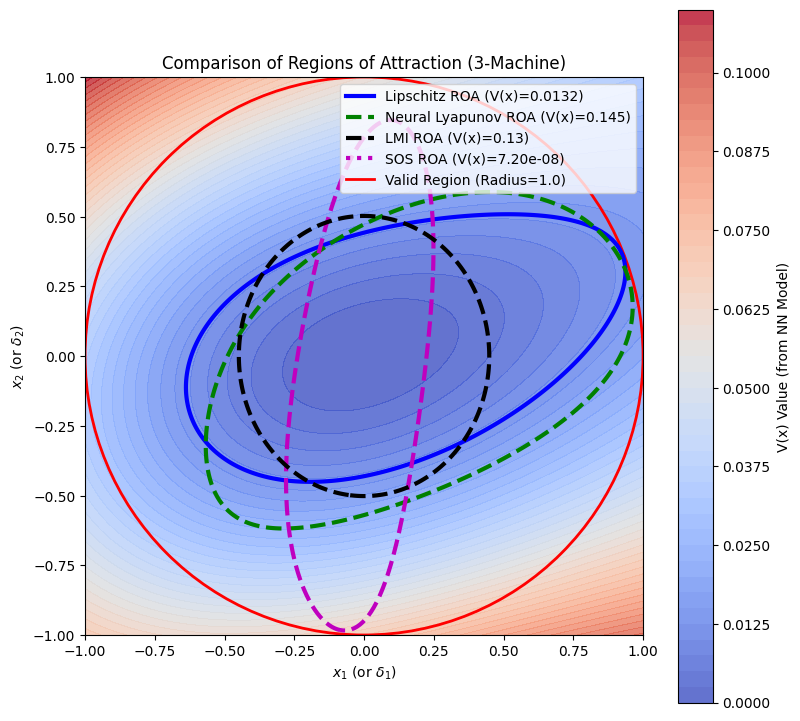


--- Calculating Area Percentages using Monte Carlo Simulation ---
Total random points generated: 1000000
Points falling inside the valid region (unit circle): 785570

--- Results ---
🔵 Lipschitz ROA covers approximately: 34.42% of the valid region.
🟢 Neural Lyapunov ROA covers approximately: 41.34% of the valid region.
🟣 LMI ROA covers approximately: 22.54% of the valid region.
💠 Taylor ROA covers approximately: 21.92% of the valid region.


In [ ]:
# @title 合并绘制四个ROA (Lipschitz, Neural, LMI, Poly) 并计算面积

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm

# --- 步骤 1: 加载神经网络模型 (NN ROA - 蓝色实线) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )
    def forward(self, x):
        phi = self.phi_network(x)
        # V is defined as the sum of squares of the phi network outputs
        return torch.sum(phi**2, dim=-1, keepdim=True)

# 定义模型参数 (来自你的 3MG 代码)
D_IN, H1, D_PHI_OUT = 3, 32, 3
MODEL_LOAD_PATH = "lyapunov_only_model_3MG.pt"

# 初始化并加载模型
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
try:
    loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    loaded_model.eval()
    print(f"✅ NN Model (Lipschitz) loaded successfully from: {MODEL_LOAD_PATH}")
except FileNotFoundError:
    print(f"❌ Error: Model file not found at '{MODEL_LOAD_PATH}'. Please upload the model file.")
    # Exit or handle the error appropriately
    exit()


# --- 步骤 2: 定义各种Lyapunov函数 ---

# 2.1: 手动函数 (Neural Lyapunov ROA - 绿色虚线)
def V_manual_func(x1, x2, x3):
    # 这是你 3MG 代码里的 tanh 函数
    return np.tanh((0.2547767162322998 - 0.40649959444999695 * np.tanh((-0.81863176822662354 - 0.0090384278446435928 * x1 - 0.013131312094628811 * x2 + 0.041521396487951279 * x3)) + 0.57938146591186523 * np.tanh((-0.75359994173049927 - 0.53954482078552246 * x1 + 0.92261224985122681 * x2 + 0.67998963594436646 * x3)) + 0.41757205128669739 * np.tanh((-0.67490863800048828 - 0.58315283060073853 * x1 + 0.89021241664886475 * x2 - 0.96415972709655762 * x3)) - 0.52628910541534424 * np.tanh((-0.62299853563308716 - 0.011999349109828472 * x1 - 0.033917032182216644 * x2 + 0.0091249439865350723 * x3)) + 0.46008062362670898 * np.tanh((-0.56307429075241089 - 0.52978396415710449 * x1 - 1.0726710557937622 * x2 - 0.018526552245020866 * x3)) + 0.50381451845169067 * np.tanh((-0.55930608510971069 + 1.0690319538116455 * x1 - 0.45746400952339172 * x2 + 0.14372418820858002 * x3)) - 0.10210692137479782 * np.tanh((-0.1813347339630127 - 0.19584846496582031 * x1 + 0.12685427069664001 * x2 + 0.12084156274795532 * x3)) + 0.52733159065246582 * np.tanh((0.58528244495391846 + 0.018898408859968185 * x1 + 0.010899221524596214 * x2 + 0.019925747066736221 * x3))))

# 2.3: 【新】Polynomial Lyapunov 函数 (Poly ROA - 青色点线)
def V_poly_func(x1, x2, x3):
    # 这个函数只用了 x1 和 x2 (x3被忽略)，这没问题，因为我们画的是x3=0的切片
    V = (5.91e-8 * x1**4 +
         1.486e-7 * x1**3 * x2 +
         3.54e-7 * x1**3 +
         1.601e-7 * x1**2 * x2**2 +
         1.656e-7 * x1**2 * x2 +
         1.35e-6 * x1**2 +
         9.638e-8 * x1 * x2**3 -
         8.883e-8 * x1 * x2**2 -
         3.691e-7 * x1 * x2 +
         3.038e-8 * x2**4 +
         2.654e-8 * x2**3 +
         7.775e-8 * x2**2)
    return V

# 2.2: LMI Lyapunov 函数 (LMI ROA - 品红虚线)
def V_LMI_func(x1, x2, x3):
    # 这就是你给的那个 LMI 函数
    V = (x1*((726740612259899*x1)/1125899906842624 - (375005997332307*x2)/9671406556917033397649408 + (800829822797503*x3)/9671406556917033397649408)
         - x2*((375005997332307*x1)/9671406556917033397649408 - (580607185267217*x2)/1125899906842624 + (1553529711554555*x3)/18014398509481984)
         + x3*((800829822797503*x1)/9671406556917033397649408 - (1553529711554555*x2)/18014398509481984 + (5037159836491261*x3)/9007199254740992))
    return V



# --- 步骤 3: 准备绘图网格并计算 V(x) 值 ---
# 使用统一的、更密集的网格
axis_range = np.linspace(-1, 1, 200)
X1, X2 = np.meshgrid(axis_range, axis_range)
X3 = np.zeros_like(X1) # 2D 绘图，x3 切片为 0

# 为 NN ROA (Lipschitz) 计算V值
grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
with torch.no_grad():
    V_vals_nn = loaded_model(grid_tensor).cpu().numpy().reshape(X1.shape)

# 为 Manual ROA (Neural Lyapunov) 计算V值
V_vals_manual = V_manual_func(X1, X2, X3)

# 【新】为 Poly ROA 计算V值
V_vals_poly = V_poly_func(X1, X2, X3)

# 为 LMI ROA 计算V值
V_vals_LMI = V_LMI_func(X1, X2, X3)




# --- 步骤 4: 绘制组合的2D等高线图 ---
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
plt.style.use('default')

# 定义四个ROA的等高线水平
c_level_nn = 0.0132      # 蓝色实线 (Lipschitz)
c_level_manual = 0.145   # 绿色虚线 (Neural Lyapunov)
c_level_LMI = 0.13       # 品红虚线 (LMI)

# [!!] 关键：在这里为你新的 Poly ROA 填入正确的 gamma 值 [!!]
c_level_poly = 7.2e-8      # <--- !!! 在这里修改为你Poly算出的gamma值 !!! (1e-8是占位符)

# 绘制背景：使用NN模型的V(x)值作为填充背景
c1 = ax.contourf(X1, X2, V_vals_nn, levels=50, cmap='coolwarm', alpha=0.8)
fig.colorbar(c1, ax=ax, label='V(x) Value (from NN Model)')

# 绘制 NN ROA (Lipschitz) 的边界线 (蓝色)
ax.contour(X1, X2, V_vals_nn - c_level_nn, levels=[0], colors='blue', linewidths=3)

# 绘制 Manual ROA (Neural Lyapunov) 的边界线 (绿色)
ax.contour(X1, X2, V_vals_manual - c_level_manual, levels=[0], colors='green', linewidths=3, linestyles='--')

# 【新】绘制 Poly ROA 的边界线 (青色)
ax.contour(X1, X2, V_vals_poly - c_level_poly, levels=[0], colors='m', linewidths=3, linestyles='--')

# 绘制 LMI ROA 的边界线 (品红色)
ax.contour(X1, X2, V_vals_LMI - c_level_LMI, levels=[0], colors='black', linewidths=3, linestyles='--')



# 绘制红色的有效区域圆圈
valid_region_circle = plt.Circle((0, 0), 1.0, color='red', linestyle='-', linewidth=2, fill=False)
ax.add_artist(valid_region_circle)

# 设置图表属性
ax.set_title('Comparison of Regions of Attraction (3-Machine)')
ax.set_xlabel('$x_1$ (or $\delta_1$)')
ax.set_ylabel('$x_2$ (or $\delta_2$)')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')

# 创建图例
nn_line = mlines.Line2D([], [], color='blue', linewidth=3, label=f'Lipschitz ROA (V(x)={c_level_nn})')
manual_line = mlines.Line2D([], [], color='green', linestyle='--', linewidth=3, label=f'Neural Lyapunov ROA (V(x)={c_level_manual})')
poly_line = mlines.Line2D([], [], color='m', linestyle=':', linewidth=3, label=f'SOS ROA (V(x)={c_level_poly:.2e})') # 【新】
LMI_line = mlines.Line2D([], [], color='black', linestyle='--', linewidth=3, label=f'LMI ROA (V(x)={c_level_LMI})')
valid_region_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=2, label='Valid Region (Radius=1.0)')
ax.legend(handles=[nn_line, manual_line, LMI_line, poly_line, valid_region_line], loc='upper right') # 【新】
plt.show()


# --- 步骤 5: 使用蒙特卡洛方法计算面积占比 ---
print("\n--- Calculating Area Percentages using Monte Carlo Simulation ---")
num_samples = 1000000  # 样本点数量，越多结果越准

# 在[-1, 1] x [-1, 1]的正方形内生成随机点
random_points = np.random.uniform(-1, 1, (num_samples, 2))
x1_rand, x2_rand = random_points[:, 0], random_points[:, 1]
x3_rand = np.zeros(num_samples) # 2D 切片，x3 = 0

# 筛选出落在有效区域（半径为1的圆）内的点
dist_sq_from_origin = x1_rand**2 + x2_rand**2
points_in_circle_mask = dist_sq_from_origin <= 1
total_points_in_circle = np.sum(points_in_circle_mask)

print(f"Total random points generated: {num_samples}")
print(f"Points falling inside the valid region (unit circle): {total_points_in_circle}")

# --- 计算 NN ROA (Lipschitz) 的面积 ---
# 仅对圆内的点进行计算
points_for_nn = torch.tensor(
    np.stack([x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask]], axis=1),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    v_nn_rand = loaded_model(points_for_nn).cpu().numpy().flatten()

points_in_nn_roa = np.sum(v_nn_rand <= c_level_nn)
percentage_nn = (points_in_nn_roa / total_points_in_circle) * 100

# --- 计算 Manual ROA (Neural Lyapunov) 的面积 ---
# 仅对圆内的点进行计算
v_manual_rand = V_manual_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_manual_roa = np.sum(v_manual_rand <= c_level_manual)
percentage_manual = (points_in_manual_roa / total_points_in_circle) * 100

# --- 计算 LMI ROA 的面积 ---
v_LMI_rand = V_LMI_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_LMI_roa = np.sum(v_LMI_rand <= c_level_LMI)
percentage_LMI = (points_in_LMI_roa / total_points_in_circle) * 100

# --- 【新】计算 Poly ROA 的面积 ---
v_poly_rand = V_poly_func(x1_rand[points_in_circle_mask], x2_rand[points_in_circle_mask], x3_rand[points_in_circle_mask])
points_in_poly_roa = np.sum(v_poly_rand <= c_level_poly)
percentage_poly = (points_in_poly_roa / total_points_in_circle) * 100


# --- 打印结果 ---
print("\n--- Results ---")
print(f"🔵 Lipschitz ROA covers approximately: {percentage_nn:.2f}% of the valid region.")
print(f"🟢 Neural Lyapunov ROA covers approximately: {percentage_manual:.2f}% of the valid region.")
print(f"🟣 LMI ROA covers approximately: {percentage_LMI:.2f}% of the valid region.")
print(f"💠 Taylor ROA covers approximately: {percentage_poly:.2f}% of the valid region.")

✅ Model loaded: lyapunov_only_model_3MG_new.pt


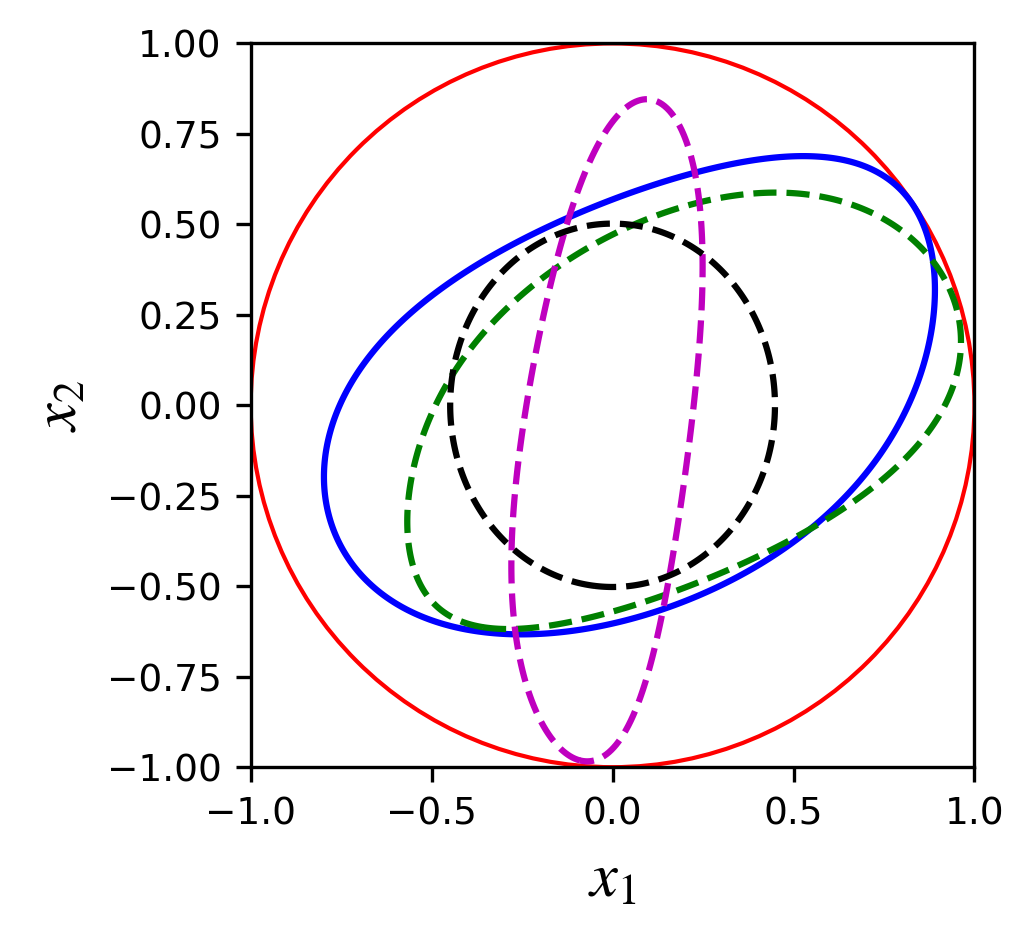

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import logging
# 将 matplotlib 的字体管理器的日志级别设置为 ERROR，这样 WARNING 就不会显示了
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- 0. 全局字体与样式设置 (IEEE TPEL 风格) ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['mathtext.fontset'] = 'stix' # 让数学公式字体更接近 Times New Roman

# --- 1. 定义网络结构与加载模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LyapunovNetwork(nn.Module):
    def __init__(self, n_input, n_hidden, n_phi_output):
        super(LyapunovNetwork, self).__init__()
        self.phi_network = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_phi_output)
        )
    def forward(self, x):
        phi = self.phi_network(x)
        return torch.sum(phi**2, dim=-1, keepdim=True)

# 定义模型参数
D_IN, H1, D_PHI_OUT = 3, 16, 3
MODEL_LOAD_PATH = "lyapunov_only_model_3MG_new.pt"

# 初始化并加载模型
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)
try:
    loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    loaded_model.eval()
    print(f"✅ Model loaded: {MODEL_LOAD_PATH}")
except FileNotFoundError:
    print(f"❌ Error: Model file '{MODEL_LOAD_PATH}' not found.")
    # 为了演示绘图，如果找不到模型，你可以注释掉 exit() 并使用随机数据，
    # 但实际运行时请确保文件存在。
    exit()

# --- 2. 定义 Lyapunov 函数 ---

# 2.1: Neural Lyapunov (Manual/Previous)
def V_manual_func(x1, x2, x3):
    return np.tanh((0.2547767162322998 - 0.40649959444999695 * np.tanh((-0.81863176822662354 - 0.0090384278446435928 * x1 - 0.013131312094628811 * x2 + 0.041521396487951279 * x3)) + 0.57938146591186523 * np.tanh((-0.75359994173049927 - 0.53954482078552246 * x1 + 0.92261224985122681 * x2 + 0.67998963594436646 * x3)) + 0.41757205128669739 * np.tanh((-0.67490863800048828 - 0.58315283060073853 * x1 + 0.89021241664886475 * x2 - 0.96415972709655762 * x3)) - 0.52628910541534424 * np.tanh((-0.62299853563308716 - 0.011999349109828472 * x1 - 0.033917032182216644 * x2 + 0.0091249439865350723 * x3)) + 0.46008062362670898 * np.tanh((-0.56307429075241089 - 0.52978396415710449 * x1 - 1.0726710557937622 * x2 - 0.018526552245020866 * x3)) + 0.50381451845169067 * np.tanh((-0.55930608510971069 + 1.0690319538116455 * x1 - 0.45746400952339172 * x2 + 0.14372418820858002 * x3)) - 0.10210692137479782 * np.tanh((-0.1813347339630127 - 0.19584846496582031 * x1 + 0.12685427069664001 * x2 + 0.12084156274795532 * x3)) + 0.52733159065246582 * np.tanh((0.58528244495391846 + 0.018898408859968185 * x1 + 0.010899221524596214 * x2 + 0.019925747066736221 * x3))))

# 2.2: LMI Lyapunov
def V_LMI_func(x1, x2, x3):
    V = (x1*((726740612259899*x1)/1125899906842624 - (375005997332307*x2)/9671406556917033397649408 + (800829822797503*x3)/9671406556917033397649408)
         - x2*((375005997332307*x1)/9671406556917033397649408 - (580607185267217*x2)/1125899906842624 + (1553529711554555*x3)/18014398509481984)
         + x3*((800829822797503*x1)/9671406556917033397649408 - (1553529711554555*x2)/18014398509481984 + (5037159836491261*x3)/9007199254740992))
    return V

# 2.3: Polynomial Lyapunov (SOS)
def V_poly_func(x1, x2, x3):
    V = (5.91e-8 * x1**4 + 1.486e-7 * x1**3 * x2 + 3.54e-7 * x1**3 +
         1.601e-7 * x1**2 * x2**2 + 1.656e-7 * x1**2 * x2 + 1.35e-6 * x1**2 +
         9.638e-8 * x1 * x2**3 - 8.883e-8 * x1 * x2**2 - 3.691e-7 * x1 * x2 +
         3.038e-8 * x2**4 + 2.654e-8 * x2**3 + 7.775e-8 * x2**2)
    return V

# --- 3. 准备数据 ---
axis_range = np.linspace(-1, 1, 300) # 稍微增加分辨率以获得更平滑的曲线
X1, X2 = np.meshgrid(axis_range, axis_range)
X3 = np.zeros_like(X1)

# 计算各方法的值
grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
with torch.no_grad():
    V_vals_nn = loaded_model(grid_tensor).cpu().numpy().reshape(X1.shape)

V_vals_manual = V_manual_func(X1, X2, X3)
V_vals_poly = V_poly_func(X1, X2, X3)
V_vals_LMI = V_LMI_func(X1, X2, X3)

# --- 4. 绘图 (Clean Version) ---
# IEEE 单栏宽度通常为 3.5 英寸，双栏通栏为 7 英寸。
# 这里设置为 3.5x3.5 使得它适合放在单栏中，或者你可以根据需要调整。
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=300)

# 定义 Levels
c_level_nn = 0.018
c_level_manual = 0.145
c_level_LMI = 0.13
c_level_poly = 7.2e-8  # <--- 请确保这里是你最终算出的值

# 设置线宽 (白色背景下，稍细一点的线看起来更精致，但为了清晰度保持在 2 左右)
lw = 1.5

# 1. Lipschitz ROA (Proposed) - 蓝色实线
ax.contour(X1, X2, V_vals_nn - c_level_nn, levels=[0], colors='blue', linewidths=lw)

# 2. Neural Lyapunov - 绿色虚线
ax.contour(X1, X2, V_vals_manual - c_level_manual, levels=[0], colors='green', linewidths=lw, linestyles='--')

# 3. SOS (Poly) - 品红点线
ax.contour(X1, X2, V_vals_poly - c_level_poly, levels=[0], colors='m', linewidths=lw, linestyles='--')

# 4. LMI - 黑色划线
ax.contour(X1, X2, V_vals_LMI - c_level_LMI, levels=[0], colors='black', linewidths=lw, linestyles='--')

# 5. Valid Region - 红色实线
valid_circle = plt.Circle((0, 0), 1.0, color='red', linestyle='-', linewidth=1.0, fill=False)
ax.add_artist(valid_circle)

# 坐标轴设置
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')

# 优化 Grid 和 Ticks (可选，TPEL 图表通常比较干净，不强制要求 grid)
# ax.grid(True, linestyle=':', alpha=0.3)

# 创建图例 (只包含线条，不包含背景色)
# 为了更干净，图例名称可以简化
# legend_handles = [
#     mlines.Line2D([], [], color='blue', linewidth=lw, label='Proposed (Lipschitz)'),
#     mlines.Line2D([], [], color='green', linestyle='--', linewidth=lw, label='Neural Lyapunov'),
#     mlines.Line2D([], [], color='m', linestyle=':', linewidth=lw, label='SOS'),
#     mlines.Line2D([], [], color='black', linestyle='-.', linewidth=lw, label='LMI'),
#     mlines.Line2D([], [], color='red', linestyle='-', linewidth=1.0, label='Verification Region')
# ]

# 图例位置：根据图中空白位置调整，通常 upper right 或 upper left
# frameon=True 给图例加个白框遮挡后面的线，frameon=False 则透明
# ax.legend(handles=legend_handles, loc='upper right', frameon=True, edgecolor='black', fancybox=False, framealpha=0.9)

plt.tight_layout()
plt.show()

# 如果需要保存图片
# fig.savefig('ROA_comparison_clean.pdf', format='pdf', bbox_inches='tight')
# fig.savefig('ROA_comparison_clean.png', format='png', dpi=600, bbox_inches='tight')

In [ ]:
# @title 8. Standalone Visualization (Split into two 3.5x3.5 plots)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import logging

# 屏蔽字体警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# --- 步骤 1: 参数设置 ---
D_IN = 3
H1 = 16
D_PHI_OUT = 3
VERIFICATION_RADIUS = 1
GRID_DENSITY = 30

# 假设 helper functions 已定义 (linearize_dynamics, get_Lf, get_Lv_and_threshold)
# 如果没有定义，请确保在此单元格之前运行了定义它们的单元格
try:
    x_0 = torch.zeros([1, D_IN]).to(device)
    A_matrix = linearize_dynamics(f_value, x_0)
    L_f = get_Lf(A_matrix)
    TAU = VERIFICATION_RADIUS * np.sqrt(D_IN) / GRID_DENSITY
    print("--- Parameters Loaded ---")
    print(f"Verification Radius: {VERIFICATION_RADIUS}, L_f: {L_f:.4f}, Tau: {TAU:.4f}")
except NameError:
    print("⚠️ Warning: Helper functions (linearize_dynamics, etc.) not found. Using dummy values for demo.")
    L_f, TAU = 1.0, 0.1

# --- 步骤 2: 加载模型 ---
MODEL_LOAD_PATH = "lyapunov_only_model_3MG_new.pt"
loaded_model = LyapunovNetwork(D_IN, H1, D_PHI_OUT).to(device)

try:
    loaded_model.load_state_dict(torch.load(MODEL_LOAD_PATH, map_location=device))
    loaded_model.eval()
    print(f"✅ Model successfully loaded from: {MODEL_LOAD_PATH}")
except FileNotFoundError:
    print(f"❌ Error: Model file not found. Ensure '{MODEL_LOAD_PATH}' exists.")
    loaded_model = None

if loaded_model:
    # --- 步骤 3: 准备数据 ---
    # a. 绘图网格
    plot_axis = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, 100)
    X1, X2 = np.meshgrid(plot_axis, plot_axis)
    X3 = np.zeros_like(X1)
    plot_grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
    plot_grid_tensor = torch.tensor(plot_grid_points, dtype=torch.float32).to(device)

    # b. 验证网格 (用于计算阈值)
    axis_verify = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, GRID_DENSITY)
    grid_verify = np.meshgrid(axis_verify, axis_verify, axis_verify)
    verification_points = np.stack([g.ravel() for g in grid_verify], axis=1)
    verification_points = verification_points[np.linalg.norm(verification_points, axis=1) <= VERIFICATION_RADIUS]
    verification_grid = torch.tensor(verification_points, dtype=torch.float32).to(device)

    # --- 步骤 4: 计算数值 ---
    # V(x)
    V_vals_2d = loaded_model(plot_grid_tensor).detach().cpu().numpy().reshape(X1.shape)

    # V_dot(x)
    plot_grid_tensor.requires_grad_(True)
    f_grid_2d = f_value(plot_grid_tensor) # 确保 f_value 已定义
    V_grid_2d = loaded_model(plot_grid_tensor)
    grad_V_grid_2d = torch.autograd.grad(V_grid_2d, plot_grid_tensor, grad_outputs=torch.ones_like(V_grid_2d))[0]
    plot_grid_tensor.requires_grad_(False)
    lie_derivative_grid_2d = torch.sum(grad_V_grid_2d * f_grid_2d, dim=1, keepdim=True).detach().cpu().numpy().reshape(X1.shape)

    # Threshold
    # 如果 get_Lv_and_threshold 未定义，这里可能会报错。确保前置代码已运行。
    try:
        L_v, threshold_val = get_Lv_and_threshold(loaded_model, verification_grid, L_f, TAU)
    except NameError:
        threshold_val = 0.0 # Fallback

    threshold_plane_2d = np.full_like(X1, threshold_val)

    # --- 步骤 5: 绘图 (分开绘制) ---

    # 全局字体设置
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 9
    plt.rcParams['axes.labelsize'] = 15 # 稍微调小一点以适应 3.5inch
    plt.rcParams['xtick.labelsize'] = 9
    plt.rcParams['ytick.labelsize'] = 9
    plt.rcParams['legend.fontsize'] = 9
    plt.rcParams['mathtext.fontset'] = 'stix'

    # ==========================
    # 图 1: V(x) Landscape
    # ==========================
    fig1 = plt.figure(figsize=(3.5, 3.5), dpi=300) # 3.5 inch square
    ax1 = fig1.add_subplot(111, projection='3d')

    # 绘图
    surf1 = ax1.plot_surface(X1, X2, V_vals_2d, cmap='YlGnBu', edgecolor='none', alpha=0.9)

    # 设置标签 (移除 Z label, Title, Colorbar)
    ax1.set_xlabel('$x_1$')
    ax1.set_ylabel('$x_2$')
    # ax1.set_zlabel('$V$')
    # 手动设置刻度，例如只显示 -1, -0.5, 0, 0.5, 1
    # 这里的 np.linspace(-1, 1, 5) 会生成 5 个点，比默认的疏很多
    ticks = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, 5)

    ax1.set_xticks(ticks)
    ax1.set_yticks(ticks)
    # x=0.0, y=1.05 表示在坐标轴边框的左上角上方一点点
    # ax1.text2D(0.0, 0.9, '(a)', transform=ax1.transAxes)
    # ax1.set_zlabel('') # Explicitly empty

    # 调整视角 (可选)
    ax1.view_init(elev=30, azim=-45)

    # 去除多余留白
    plt.tight_layout()
    plt.show()
    # fig1.savefig('Vx_landscape.pdf', bbox_inches='tight') # 可选：保存

    # ==========================
    # 图 2: V_dot(x) vs Threshold
    # ==========================
    fig2 = plt.figure(figsize=(3.5, 3.5), dpi=300) # 3.5 inch square
    ax2 = fig2.add_subplot(111, projection='3d')

    # 绘制 V_dot 曲面
    ax2.plot_surface(X1, X2, lie_derivative_grid_2d, cmap='YlGnBu', edgecolor='none', alpha=0.8)

    # 绘制 Threshold 平面 (使用 Crimson 以获得最佳对比度，如之前讨论)
    ax2.plot_surface(X1, X2, threshold_plane_2d, alpha=0.3, color='gray')

    # 设置标签
    ax2.set_xlabel('$x_1$')
    ax2.set_ylabel('$x_2$')
    # ax2.text2D(0.0, 0.9, '(b)', transform=ax2.transAxes)
    # ax2.set_zlabel('$V$')
    # 手动设置刻度，例如只显示 -1, -0.5, 0, 0.5, 1
    # 这里的 np.linspace(-1, 1, 5) 会生成 5 个点，比默认的疏很多
    ticks = np.linspace(-VERIFICATION_RADIUS, VERIFICATION_RADIUS, 5)

    ax2.set_xticks(ticks)
    ax2.set_yticks(ticks)
    ax2.set_zticks([-0.16,-0.12,-0.08,-0.04,0.00])
    # ax2.set_zlabel('')

    # 图例 (匹配平面颜色)
    plane_leg = plt.Rectangle((0, 0), 1.2, 1.2, fc="gray", alpha=0.3)
    # legend 位置微调，避免遮挡
    # (0.5, 1.02) 表示在图的水平中心(0.5)，垂直方向稍微高出一点(1.02)
    ax2.legend([plane_leg], [f'Lipschitz Threshold ({threshold_val:.4f})'],
           loc='lower center', bbox_to_anchor=(0.5, 0.95),
           frameon=True, fancybox=False, framealpha=0.8)

    # 调整视角
    ax2.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.show()
    # fig2.savefig('Vdot_check.pdf', bbox_inches='tight') # 可选：保存

--- Parameters Loaded ---
Verification Radius: 1, L_f: 1.2144, Tau: 0.0577


OSError: [Errno 107] Transport endpoint is not connected: 'lyapunov_only_model_3MG_new.pt'

In [ ]:
# @title 9. Plotting the 2D Region of Attraction (ROA)

# --- 步骤 1: 计算ROA的边界值 c_max ---
# ROA的边界是V(x)的某条等值线。这个值c_max的确定原则是：
# 在所有不满足Lipschitz导数条件的点中，找到V(x)值最小的那个点，这个V(x)值就是c_max。
# 这意味着，所有V(x) < c_max的点，其导数条件都是满足的。

# 找到所有违反条件 (V_dot + V > threshold) 的点
unsafe_mask = V_dot_check_vals > threshold_val

# V_vals是在完整的(-1,1)网格上计算的，所以我们可以直接使用它
# 我们只关心在验证球体内部的违规点
unsafe_mask_in_ball = unsafe_mask & mask.reshape(X1.shape)

if np.any(unsafe_mask_in_ball):
    # 如果存在违规点，c_max就是这些点中V(x)值的最小值
    c_max = np.min(V_vals[unsafe_mask_in_ball])
    print(f"Violation detected. ROA boundary is at V(x) = {c_max:.4f}")
else:
    # 如果在验证球体内没有违规点，则整个球体都是ROA
    # c_max就是球体边界上V(x)的最大值
    c_max = np.nanmax(V_vals)
    print(f"No violation detected within the verification radius. The entire region is the ROA.")


# --- 步骤 2: 绘制2D图像 ---
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plt.style.use('default') # 使用默认样式以获得白色背景

# 绘制背景：V(x) 的填充等高线图，以显示其“碗”状形态
c1 = ax.contourf(X1, X2, V_vals, levels=20, cmap='coolwarm')
fig.colorbar(c1, ax=ax, label='V(x) Value')

# 绘制细的黑色等高线，增加细节
ax.contour(X1, X2, V_vals, levels=20, linewidths=0.5, colors='none')

# --- 步骤 3: 绘制ROA的边界线 (核心) ---
# 这条红线就是 V(x) = c_max 的等值线
ax.contour(X1, X2, V_vals, levels=[c_max], colors='red', linewidths=3)

# 步骤 4: 绘制我们进行验证的区域边界
verification_circle = plt.Circle((0, 0), VERIFICATION_RADIUS, color='red', linestyle='-', linewidth=2, fill=False)
ax.add_artist(verification_circle)


# 设置图表属性
ax.set_title('Estimated Region of Attraction (ROA) of V(x)')
ax.set_xlabel('δ1')
ax.set_ylabel('δ2')
# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')

# 创建图例
red_line = mlines.Line2D([], [], color='red', linewidth=3, label=f'ROA Boundary (V(x)={c_max:.4f})')
dashed_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label=f'Verification Region (Radius={VERIFICATION_RADIUS})')
ax.legend(handles=[red_line, dashed_line], loc='upper right')

plt.show()

NameError: name 'V_dot_check_vals' is not defined

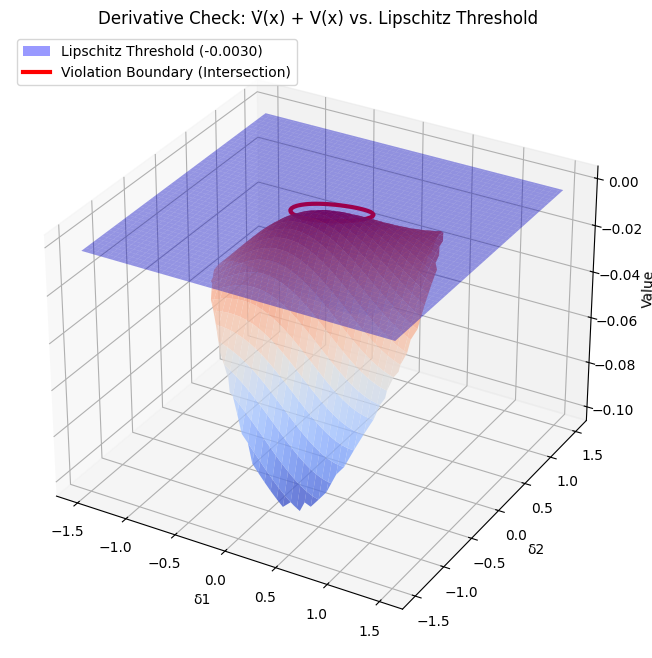


--- Programmatic Verification Verdict ---
❌ Verification FAILED.
   The V̇(x) + V(x) surface IS above the Lipschitz threshold plane.
   Violation percentage within the ball: 5.53%


In [ ]:
# @title 8. Visualize the Learned Function and Lipschitz Condition (with Intersection and Verdict)
import matplotlib.lines as mlines

model.eval()

# Create a 2D slice of the state space (x3 = 0)
axis = np.linspace(-1.5, 1.5, 100)
X1, X2 = np.meshgrid(axis, axis)
X3 = np.zeros_like(X1)

grid_points = np.stack([X1.ravel(), X2.ravel(), X3.ravel()], axis=1)
# Filter points to be within the ball for a circular plot
mask = np.linalg.norm(grid_points, axis=1) <= 1
grid_points = grid_points[mask]

grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)

# --- Re-calculate values for the final plot ---
# V(x) - No need to recalculate if not plotting it again
# V_vals = model(grid_tensor).detach().cpu().numpy().reshape(X1.shape)

# V_dot + V
grid_tensor.requires_grad_(True)
f_grid = f_value(grid_tensor)
V_grid = model(grid_tensor)
grad_V_grid = torch.autograd.grad(V_grid, grid_tensor, grad_outputs=torch.ones_like(V_grid))[0]
grid_tensor.requires_grad_(False)
lie_derivative_grid = torch.sum(grad_V_grid * f_grid, dim=1, keepdim=True)

# Important: Use detach() before converting to numpy
V_dot_check_vals_flat = (lie_derivative_grid + V_grid).detach().cpu().numpy().ravel()

# Create a full grid for plotting, and fill with NaNs where points are outside the radius
V_dot_check_vals = np.full_like(X1, np.nan)
V_dot_check_vals.ravel()[mask] = V_dot_check_vals_flat


# Threshold
L_v, threshold_val = get_Lv_and_threshold(model, grid_tensor, L_f, TAU)
threshold_plane = np.full_like(X1, threshold_val)
# --- End of calculations ---


# Plotting
fig = plt.figure(figsize=(10, 8)) # Adjusted for a single plot

# Plot V_dot(x) + V(x) with verification plane
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, V_dot_check_vals, cmap='coolwarm', edgecolor='none', alpha=0.8)
ax.plot_surface(X1, X2, threshold_plane, alpha=0.4, color='blue')

# --- 新增功能：绘制交线 ---
# The intersection occurs where the difference between the surface and the plane is 0
difference = V_dot_check_vals - threshold_plane
ax.contour(X1, X2, difference, levels=[0], colors='red', linewidths=3)
# --- 功能结束 ---

ax.set_title('Derivative Check: V̇(x) + V(x) vs. Lipschitz Threshold')
ax.set_xlabel('δ1')
ax.set_ylabel('δ2')
ax.set_zlabel('Value')

# Create custom legend entries
blue_plane_leg = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.4)
intersection_line_leg = mlines.Line2D([], [], color='red', linewidth=3)
ax.legend([blue_plane_leg, intersection_line_leg],
          [f'Lipschitz Threshold ({threshold_val:.4f})', 'Violation Boundary (Intersection)'],
          loc='upper left')

plt.show()


# --- 新增功能：程序化判断 ---
print("\n--- Programmatic Verification Verdict ---")
# Check if any point on the surface is above the threshold plane
# We use the calculated flat array before filling with NaNs
is_violated = np.any(V_dot_check_vals_flat > threshold_val)

if is_violated:
    violation_percentage = np.mean(V_dot_check_vals_flat > threshold_val) * 100
    print(f"❌ Verification FAILED.")
    print(f"   The V̇(x) + V(x) surface IS above the Lipschitz threshold plane.")
    print(f"   Violation percentage within the ball: {violation_percentage:.2f}%")
else:
    print(f"✅ Verification PASSED.")
    print(f"   The V̇(x) + V(x) surface is entirely below the Lipschitz threshold plane.")
# --- 功能结束 ---